In [111]:
import mcstasscript as ms
import mcstastox as mx
import scipp as sc
from scipp.typing import VariableLike
import scipp as sc
import matplotlib.pyplot as plt
from scippneutron.conversion.graph.beamline import beamline
import numpy as np

import os
import sys 
sys.path.append("/Users/bb24144/Documents/McStas/reduction_plet/trex_data_reduction")
from trex_reduction import inelastic
from trex_reduction import produce_trex_event_object


parent = os.path.dirname(os.getcwd())

cspec_source_samp = {'source_name': "ESS_Source", 
                     'sample_name': "Sample"}

let_source_samp = {'source_name': "SourceMantid", 
                     'sample_name': "iso_samp"}

In [112]:
benz_folder = "CSPEC_benz_1e11"
benz_path = os.path.join(parent, "runs", benz_folder)
with mx.Read(benz_path) as loaded_data:
   benz_events = loaded_data.export_scipp_simple(**cspec_source_samp)

benz_data = ms.load_data(benz_path)


vanad_folder = "CSPEC_vanad_1e11"
vanad_path = os.path.join(parent, "runs", vanad_folder)
with mx.Read(vanad_path) as loaded_data:
   vanad_events = loaded_data.export_scipp_simple(**cspec_source_samp)

vanad_data = ms.load_data(vanad_path)

In [113]:

gap = 0

# McStas provides absolute time, not time of flight
benz_events.coords["tof"] = benz_events.coords["t"] + sc.scalar(2.86e-3/2, unit = 's')
vanad_events.coords["tof"] = vanad_events.coords["t"] + sc.scalar(2.86e-3/2, unit = 's')
# Add additional information required for inelastic scattering

benz_events = produce_trex_event_object(benz_events, benz_path, "TOF_Sample_AllLambda", gap = gap)
vanad_events = produce_trex_event_object(vanad_events, vanad_path, "TOF_Sample_AllLambda", gap = gap)
benz_events

<scipp.DataArray>
Dimensions: Sizes[events:1518992, ]
Coordinates:
* monitor_position          vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* position                  vector3              [m]  (events)  [(3.584, 1.03934, 161.357), (3.05638, -0.343067, 162.206), ..., (3.82267, -1.16652, 160.573), (2.38533, 0.274512, 162.82)]
* sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* source_position           vector3              [m]  ()  (0, 0, 0)
* t                         float64              [s]  (events)  [0.11201, 0.112643, ..., 0.142001, 0.135132]
* time_on_monitor           float64              [s]  (events)  [0.110723, 0.110723, ..., 0.140757, 0.13475]
* tof                       float64              [s]  (events)  [0.11344, 0.114073, ..., 0.143431, 0.136562]
Data:
                            float64         [counts]  (events)  [1.02522e-07, 2.10907e-21, ..., 0.00917385, 3.78615e-05]

In [114]:
qens_graph = {**beamline(scatter=True), **inelastic}

benz_events = benz_events.transform_coords("dE", graph=qens_graph)
benz_events = benz_events.transform_coords("mag_Q", graph=qens_graph)
benz_events = benz_events.transform_coords("two_theta", graph=qens_graph)

vanad_events = vanad_events.transform_coords("dE", graph=qens_graph)
vanad_events = vanad_events.transform_coords("mag_Q", graph=qens_graph)
vanad_events = vanad_events.transform_coords("two_theta", graph=qens_graph)


In [115]:
benz_events

<scipp.DataArray>
Dimensions: Sizes[events:1518992, ]
Coordinates:
  L1                        float64              [m]  ()  159.954
  L2                        float64              [m]  (events)  [3.80212, 3.50151, ..., 3.57341, 3.57341]
  Lm                        float64              [m]  ()  159.954
  Q                         vector3           [1/Å]  (events)  [(-1.86306, -0.868312, 1.47398), (-1.25905, -0.0489323, 1.22625), ..., (-2.03778, 0.427849, 1.43647), (-1.75145, -0.632093, -0.628967)]
* dE                        float64            [meV]  (events)  [0.675561, 5.19805, ..., -2.58702, -12.9827]
  incident_beam             vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  kf                        vector3           [1/Å]  (events)  [(1.87386, 0.868318, 0.820431), (1.26985, 0.0489374, 1.06817), ..., (2.04628, -0.427845, 0.368373), (1.76033, 0.632097, 2.51426)]
  ki                        vector3           [1/Å]  (events)  [(0.0108034, 5.13289e-06, 2.29442), (0.0108034, 5.13289e-06, 2.29442), ..., (0.00849818, 4.03765e-06, 1.80484), (0.008877, 4.21764e-06, 1.8853)]
* mag_Q                     float64           [1/Å]  (events)  [2.52934, 1.7582, ..., 2.52963, 1.96538]
  mag_kf                    float64           [1/Å]  (events)  [2.22226, 1.66009, ..., 2.12274, 3.13366]
  mag_ki                    float64           [1/Å]  (events)  [2.29444, 2.29444, ..., 1.80486, 1.88532]
  monitor_beam              vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  monitor_position          vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  position                  vector3              [m]  (events)  [(3.584, 1.03934, 161.357), (3.05638, -0.343067, 162.206), ..., (3.82267, -1.16652, 160.573), (2.38533, 0.274512, 162.82)]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  scattered_beam            vector3              [m]  (events)  [(3.20603, 1.48563, 1.4037), (2.67841, 0.10322, 2.25301), ..., (3.4447, -0.720233, 0.620119), (2.00736, 0.7208, 2.86709)]
  source_position           vector3              [m]  ()  (0, 0, 0)
* t                         float64              [s]  (events)  [0.11201, 0.112643, ..., 0.142001, 0.135132]
  time_on_monitor           float64              [s]  (events)  [0.110723, 0.110723, ..., 0.140757, 0.13475]
  time_on_sample            float64              [s]  (events)  [0.110723, 0.110723, ..., 0.140757, 0.13475]
  tof                       float64              [s]  (events)  [0.11344, 0.114073, ..., 0.143431, 0.136562]
* two_theta                 float64            [rad]  (events)  [1.19169, 0.869563, ..., 1.39349, 0.638317]
  unit_kf                   vector3  [dimensionless]  (events)  [(0.843223, 0.390736, 0.369188), (0.764929, 0.0294788, 0.643439), ..., (0.963982, -0.201554, 0.173537), (0.561749, 0.201712, 0.802341)]
  unit_ki                   vector3  [dimensionless]  ()  (0.00470849, 2.2371e-06, 0.999989)
  vf                        float64            [m/s]  (events)  [1399.18, 1045.23, ..., 1336.52, 1973.02]
  vi                        float64            [m/s]  (events)  [1444.63, 1444.63, ..., 1136.38, 1187.04]
Data:
                            float64         [counts]  (events)  [1.02522e-07, 2.10907e-21, ..., 0.00917385, 3.78615e-05]

In [116]:
benz_events.coords['time_on_monitor'].max()

<scipp.Variable> ()    float64              [s]  0.152773

In [128]:
def calc_e_from_v(vi):
    mag_ki = (sc.constants.neutron_mass * vi) / sc.constants.hbar
    mag_ki = sc.to_unit(mag_ki, "1/angstrom")
    E = (sc.constants.hbar**2 / (2 * sc.constants.neutron_mass)) * (
        mag_ki**2)
    return sc.to_unit(E, sc.units.meV)

calc_e_from_v(benz_events.coords['vi'].min())

<scipp.Variable> ()    float64            [meV]  5.72999

In [117]:
unit = benz_events.coords['dE'].unit
benz_mask = (benz_events.coords['dE'] > sc.scalar(-10, unit=unit)) & (benz_events.coords['dE'] < sc.scalar(10, unit=unit)) #& (benz_events.coords['time_on_monitor'] > sc.scalar(0.1521, unit='s')) & (benz_events.coords['time_on_monitor'] < sc.scalar(0.153, unit='s'))
vanad_mask = (vanad_events.coords['dE'] > sc.scalar(-10, unit=unit)) & (vanad_events.coords['dE'] < sc.scalar(10, unit=unit)) #& (vanad_events.coords['time_on_monitor'] > sc.scalar(0.1521, unit='s')) & (vanad_events.coords['time_on_monitor'] < sc.scalar(0.153, unit='s'))

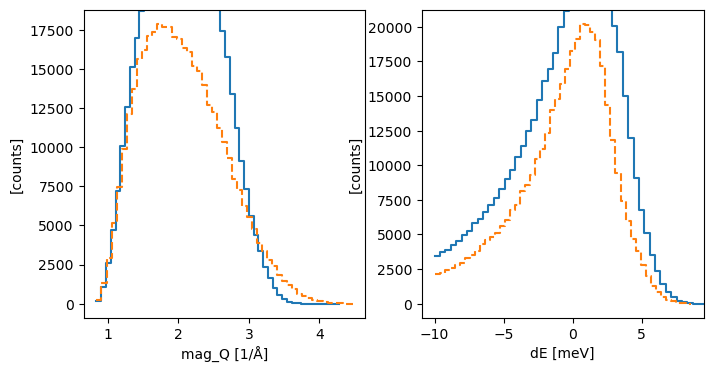

In [118]:
fig, [ax1,ax2] = plt.subplots(1,2, figsize = (8,4))
(benz_events[benz_mask].hist(mag_Q=51) * 10).plot(ax=ax1, linestyle='-', color='tab:blue') 
(vanad_events[vanad_mask].hist(mag_Q=51)).plot(ax=ax1, linestyle='--', color='tab:orange') 

(benz_events[benz_mask].hist(dE=51) * 10).plot(ax=ax2, linestyle='-', color='tab:blue') 
(vanad_events[vanad_mask].hist(dE=51)).plot(ax=ax2, linestyle='--', color='tab:orange') 


plt.show()

In [119]:
from trex_reduction import v_bin_norm

new_q = sc.linspace('mag_Q', 0.6,3,num=30, unit = '1/Angstrom')
new_omega = sc.linspace('dE', -5,5,num=300, unit = 'meV')

bin_list = [new_q,new_omega]

hist_event, hist_vanad, hist_norm = v_bin_norm(bin_list, benz_events[benz_mask], vanad_events[vanad_mask])


In [120]:
hist_event

<scipp.DataArray>
Dimensions: Sizes[mag_Q:29, dE:299, ]
Coordinates:
  L1                        float64              [m]  ()  159.954
  Lm                        float64              [m]  ()  159.954
* dE                        float64            [meV]  (dE [bin-edge])  [-5, -4.96656, ..., 4.96656, 5]
  incident_beam             vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* mag_Q                     float64           [1/Å]  (mag_Q [bin-edge])  [0.6, 0.682759, ..., 2.91724, 3]
  monitor_beam              vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  monitor_position          vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  source_position           vector3              [m]  ()  (0, 0, 0)
  unit_ki                   vector3  [dimensionless]  ()  (0.00470849, 2.2371e-06, 0.999989)
Data:
                            float64         [counts]  (mag_Q, dE)  [0, 0, ..., 0.04446, 0]

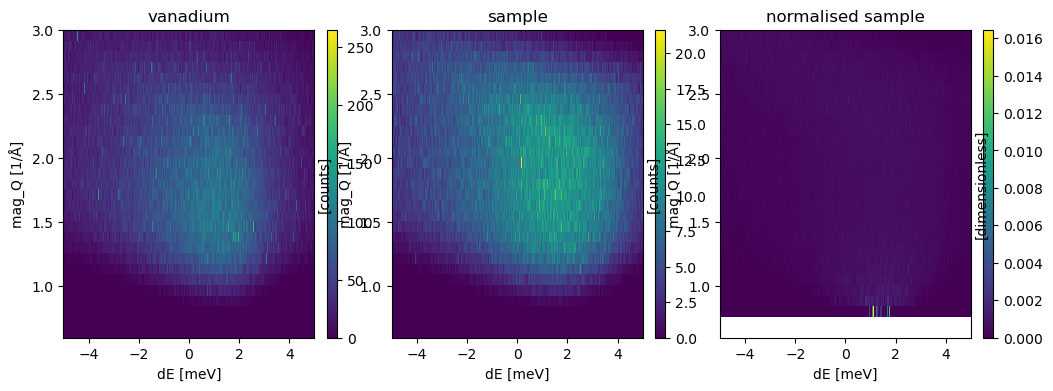

In [121]:
fig, [ax1,ax2,ax3] = plt.subplots(1,3,figsize =(12,4))


hist_vanad.plot(ax=ax1)
hist_event.plot(ax=ax2)
hist_norm.plot(ax=ax3)

ax1.set_title('vanadium')
ax2.set_title('sample')
ax3.set_title('normalised sample')
plt.show()

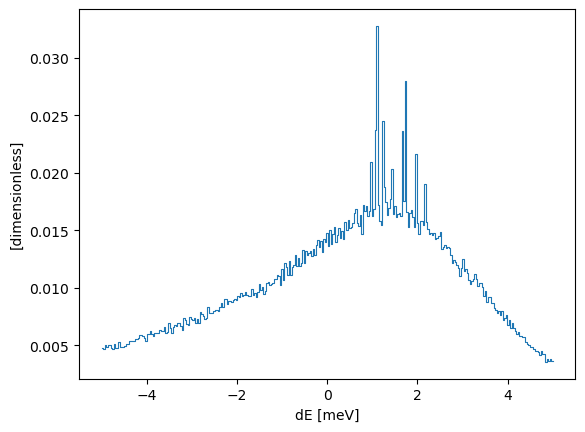

In [122]:
fig, ax = plt.subplots()
(sc.nansum(hist_norm, dim = 'mag_Q')).plot(ax = ax, linewidth=0.8)

plt.show()